In [1]:
import random
random.seed(717)
num = random.randint(1, 10)
print(num)

4


In [28]:
import pandas as pd
# Đọc dữ liệu
df = pd.read_csv("data4.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [29]:
# 1. Kích thước dữ liệu
print("Kích thước dữ liệu:", df.shape)
# 2. Kiểm tra giá trị thiếu
print("\nGiá trị thiếu ở từng cột:")
print(df.isnull().sum())
# 3. Kiểm tra trùng lặp và xoá
print("\nSố dòng trùng lặp:", df.duplicated().sum())
# 4. Thống kê mô tả
print("\nThống kê mô tả:")
print(df.describe())

Kích thước dữ liệu: (1338, 7)

Giá trị thiếu ở từng cột:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Số dòng trùng lặp: 1

Thống kê mô tả:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [4]:
#Kiểm tra outlier
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["charges"] < lower_bound) | (df["charges"] > upper_bound)]
print("Số outlier của charges:", outliers.shape[0])

Số outlier của charges: 139


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [6]:
# thống kê mô tả
print(df.describe())
print(df.describe(include="all"))

               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010
                age   sex          bmi     children smoker     region  \
count   1337.000000  1337  1337.000000  1337.000000   1337       1337   
unique          NaN     2          NaN          NaN      2          4   
top             NaN  male          NaN          NaN     no  southeast   
freq            NaN   675          NaN          NaN   1063        364   
mean      39.222139   NaN    30.663452     1.095737    NaN        NaN   
std       14.044333   NaN     6

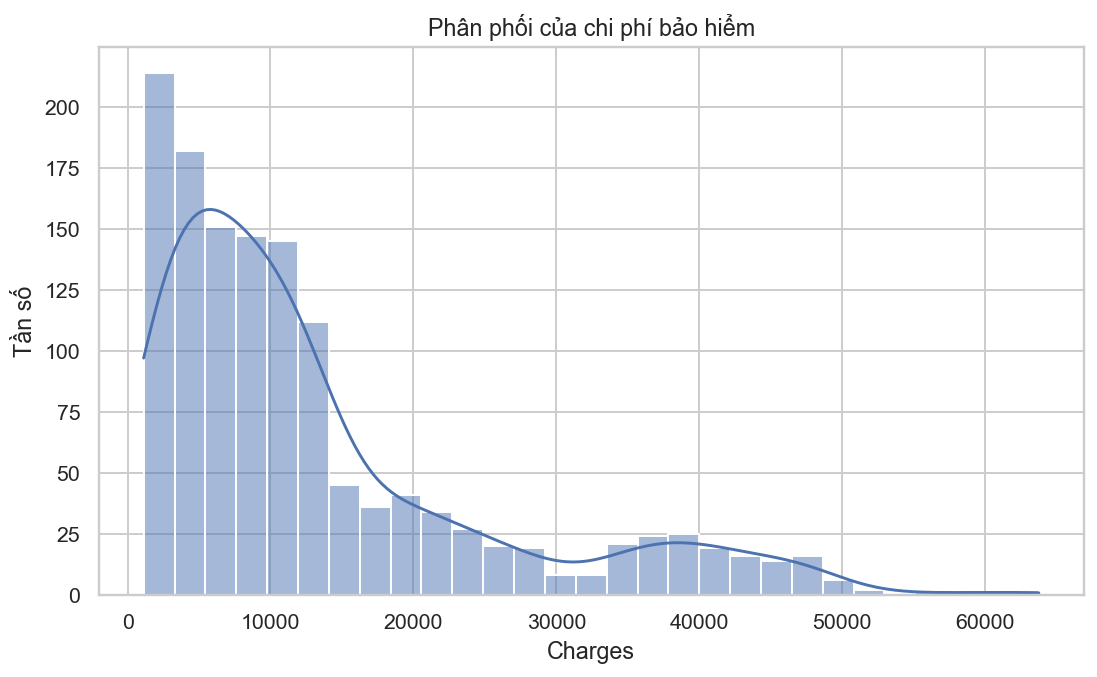

In [7]:
# kiểm tra phân phối biến charges
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 140
money_fmt = FuncFormatter(lambda x, pos: f"{x:,.0f}")
plt.figure(figsize=(8,5))
sns.histplot(df["charges"], kde=True)
plt.title("Phân phối của chi phí bảo hiểm")
plt.xlabel("Charges")
plt.ylabel("Tần số")
plt.tight_layout()
plt.show()

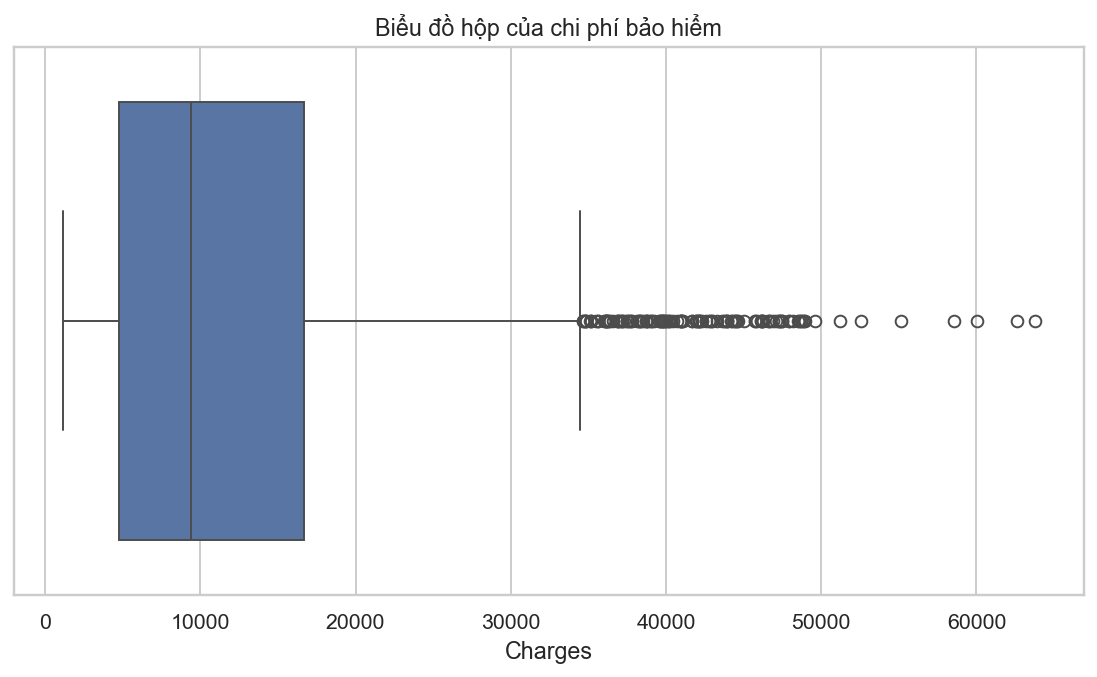

In [8]:
# biểu đồ hộp
plt.figure(figsize=(8,5))
sns.boxplot(x=df["charges"])
plt.title("Biểu đồ hộp của chi phí bảo hiểm")
plt.xlabel("Charges")
plt.tight_layout()
plt.show()

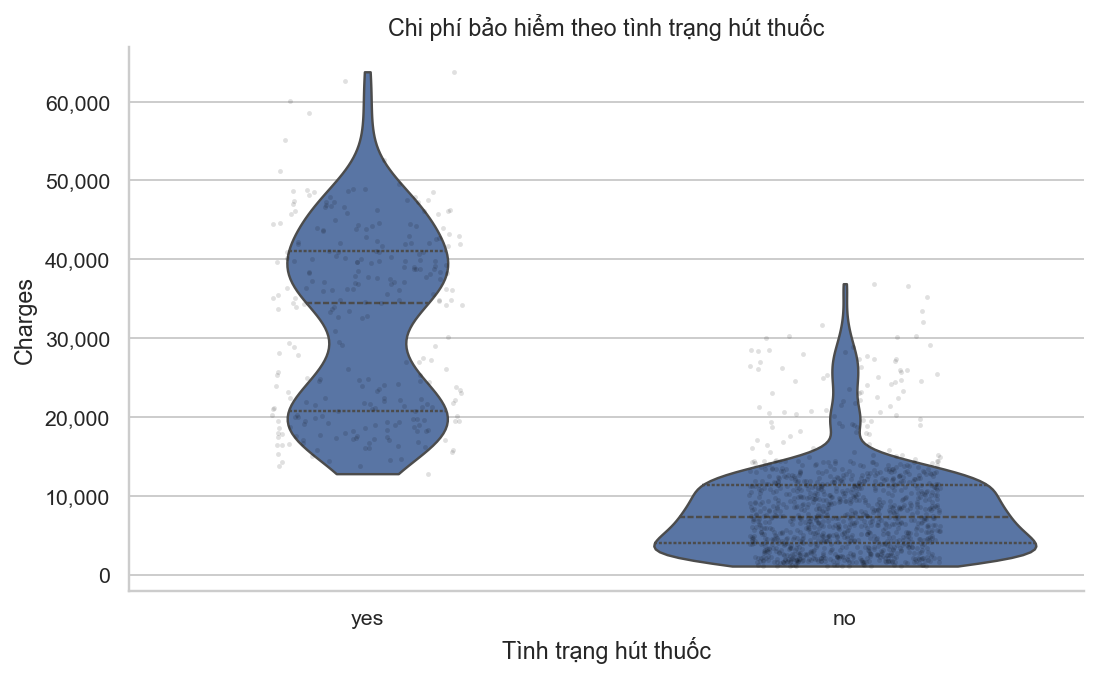

In [9]:
# charges theo smoker
plt.figure(figsize=(8,5))
ax = sns.violinplot(data=df, x="smoker", y="charges", inner="quartile", cut=0)
sns.stripplot(data=df, x="smoker", y="charges",
              color="black", alpha=0.12, size=2.5, jitter=0.2)
ax.set_title("Chi phí bảo hiểm theo tình trạng hút thuốc")
ax.set_xlabel("Tình trạng hút thuốc")
ax.set_ylabel("Charges")
ax.yaxis.set_major_formatter(money_fmt)
sns.despine()
plt.tight_layout()
plt.show()

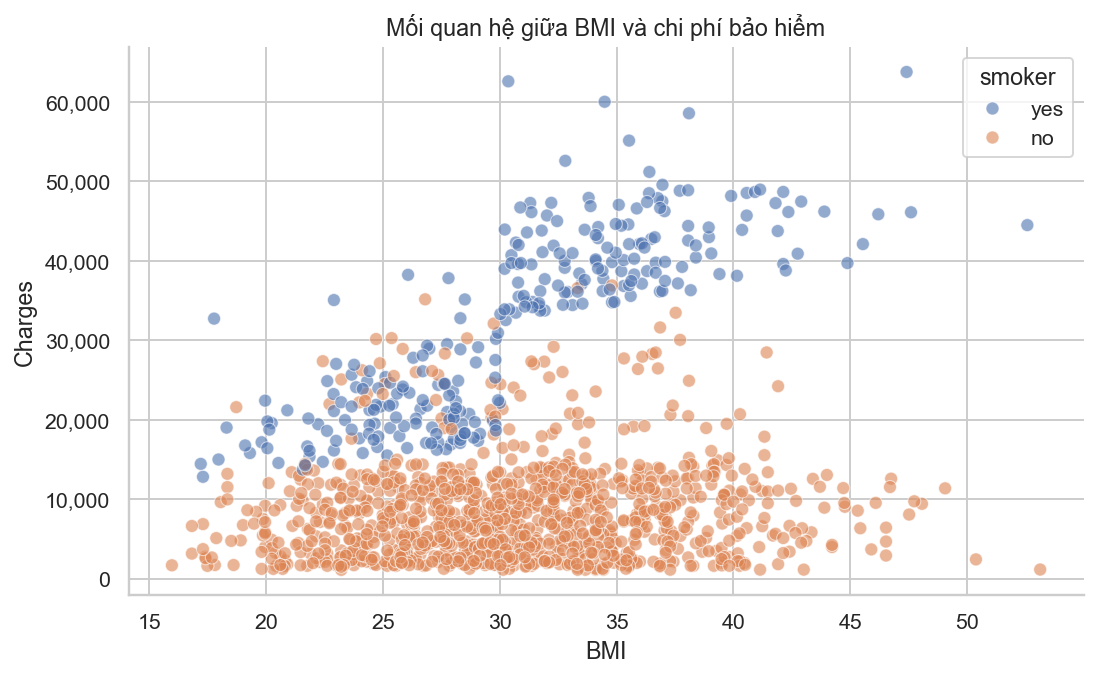

In [10]:
plt.figure(figsize=(8,5))
ax = sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.6, s=45)
ax.set_title("Mối quan hệ giữa BMI và chi phí bảo hiểm")
ax.set_xlabel("BMI")
ax.set_ylabel("Charges")
ax.yaxis.set_major_formatter(money_fmt)
sns.despine()
plt.tight_layout()
plt.show()

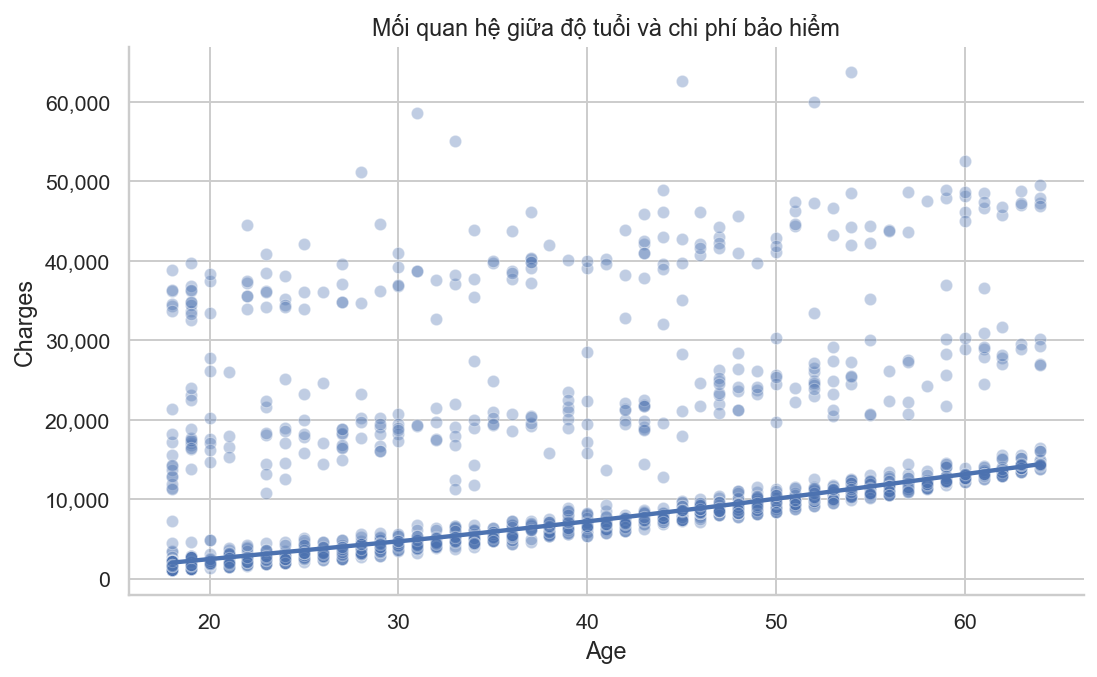

In [11]:
plt.figure(figsize=(8,5))
ax = sns.scatterplot(data=df, x="age", y="charges", alpha=0.35, s=40)
sns.regplot(data=df, x="age", y="charges", lowess=True, scatter=False, ax=ax)
ax.set_title("Mối quan hệ giữa độ tuổi và chi phí bảo hiểm")
ax.set_xlabel("Age")
ax.set_ylabel("Charges")
ax.yaxis.set_major_formatter(money_fmt)
sns.despine()
plt.tight_layout()
plt.show()

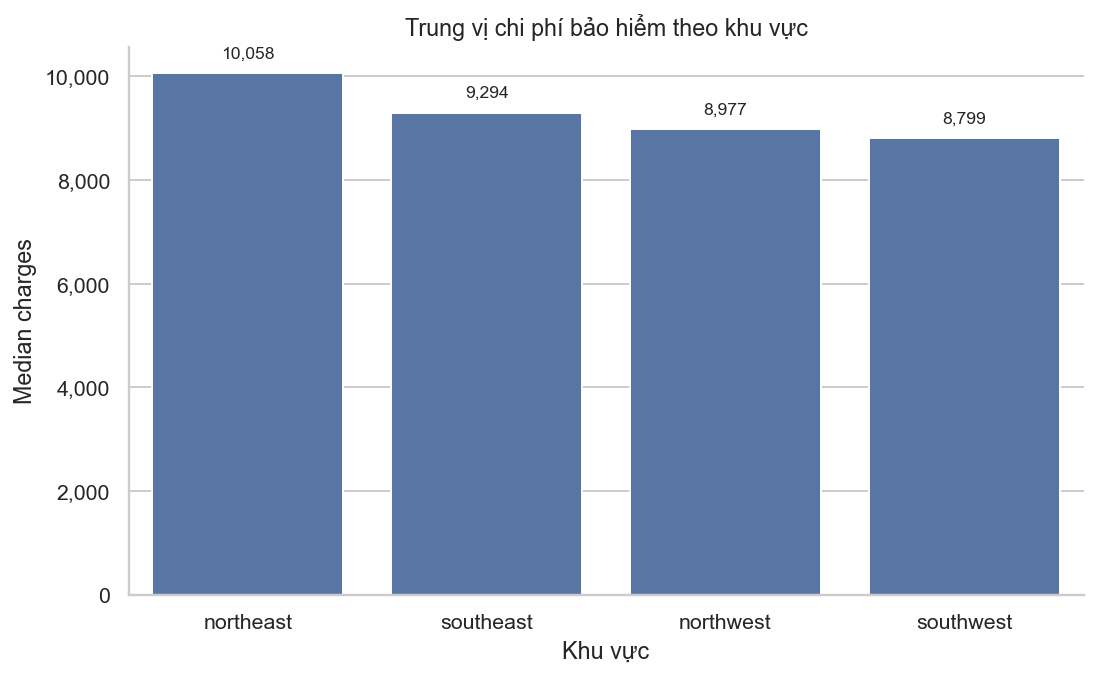

In [12]:
region_med = (
    df.groupby("region", as_index=False)["charges"]
      .median()
      .sort_values("charges", ascending=False)
)

plt.figure(figsize=(8,5))
ax = sns.barplot(data=region_med, x="region", y="charges")
ax.set_title("Trung vị chi phí bảo hiểm theo khu vực")
ax.set_xlabel("Khu vực")
ax.set_ylabel("Median charges")
ax.yaxis.set_major_formatter(money_fmt)

for i, v in enumerate(region_med["charges"]):
    ax.text(i, v + 300, f"{v:,.0f}", ha="center", fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

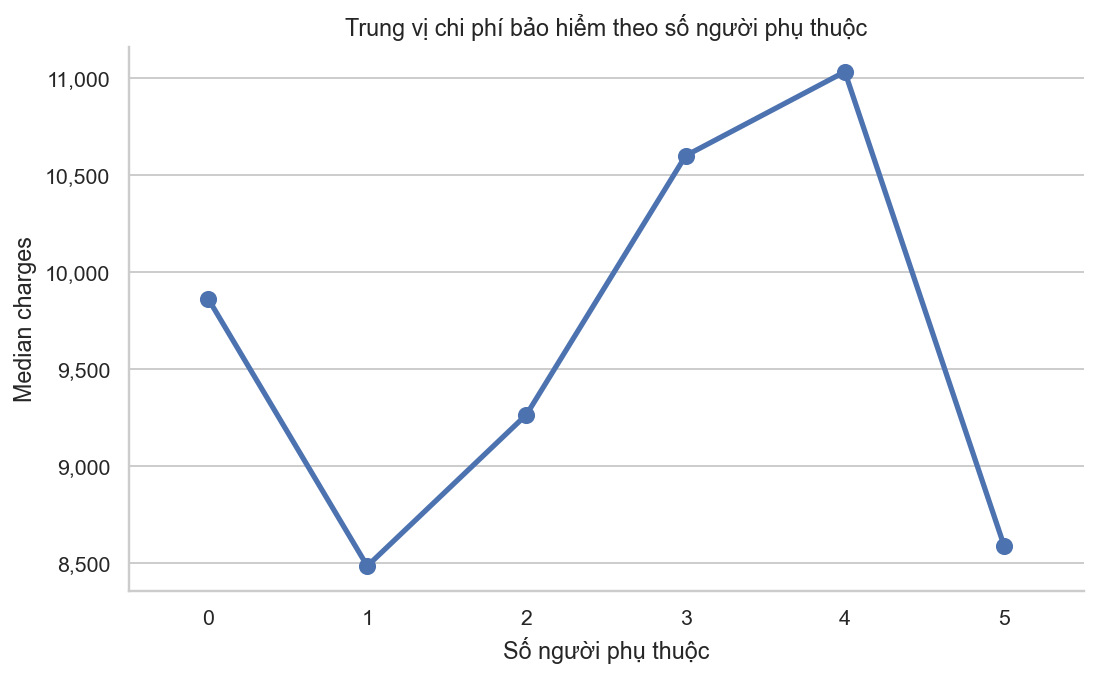

In [13]:
children_med = (
    df.groupby("children", as_index=False)["charges"]
      .median()
      .sort_values("children")
)

plt.figure(figsize=(8,5))
ax = sns.pointplot(data=children_med, x="children", y="charges")
ax.set_title("Trung vị chi phí bảo hiểm theo số người phụ thuộc")
ax.set_xlabel("Số người phụ thuộc")
ax.set_ylabel("Median charges")
ax.yaxis.set_major_formatter(money_fmt)
sns.despine()
plt.tight_layout()
plt.show()

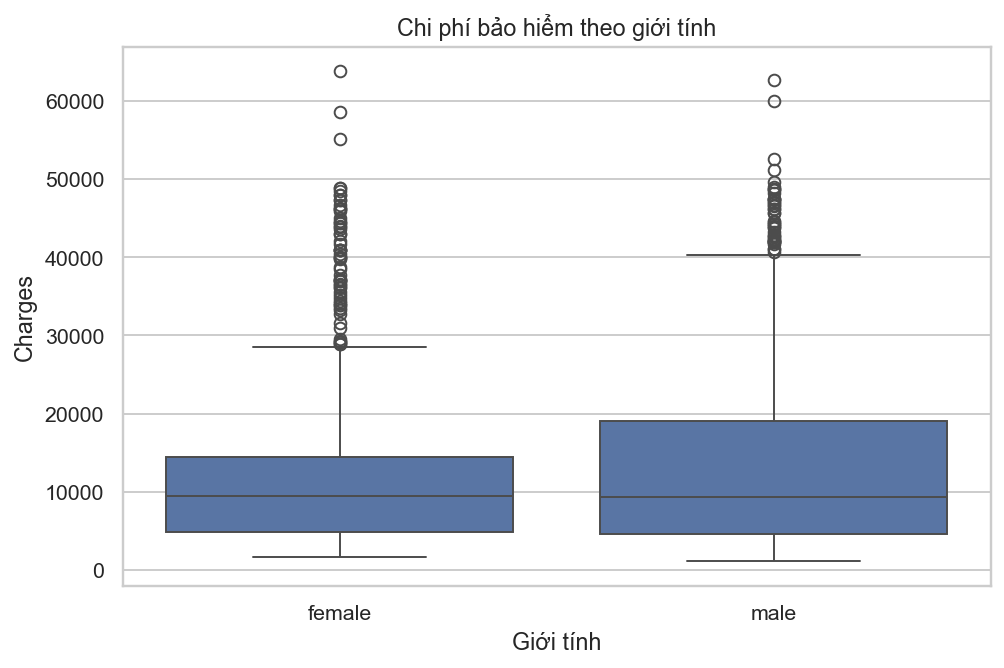

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x="sex", y="charges", data=df)
plt.title("Chi phí bảo hiểm theo giới tính")
plt.xlabel("Giới tính")
plt.ylabel("Charges")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
# Xác định biến đầu vào và biến mục tiêu
X = df[["age", "sex", "bmi", "children", "smoker", "region"]]
y = df["charges"]

In [17]:
# Chia tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
# Phân loại biến số và biến phân loại
num_features = ["age", "bmi", "children"]
cat_features = ["sex", "smoker", "region"]

In [19]:
# Tiền xử lý dữ liệu
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features)
])

In [20]:
# Tạo pipeline mô hình
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [21]:
# Huấn luyện mô hình
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('regressor', LinearRegression())])

In [22]:
# Dự đoán
y_pred = model.predict(X_test)

In [23]:
# Đánh giá mô hình
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 4177.045561036324
RMSE: 5956.342894363587
R2: 0.8069287081198012


In [24]:
#Mô hình hồi quy cải thiện với biến tương tác 

df["smoker_num"] = df["smoker"].map({"yes": 1, "no": 0})
df["bmi_smoker"] = df["bmi"] * df["smoker_num"]
df["age_smoker"] = df["age"] * df["smoker_num"]

X = df[["age", "sex", "bmi", "children", "smoker", "region", "bmi_smoker", "age_smoker"]]
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_features = ["age", "bmi", "children", "bmi_smoker", "age_smoker"]
cat_features = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), cat_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2831.646977737175
RMSE: 4577.779551062793
R2: 0.8859571479859213


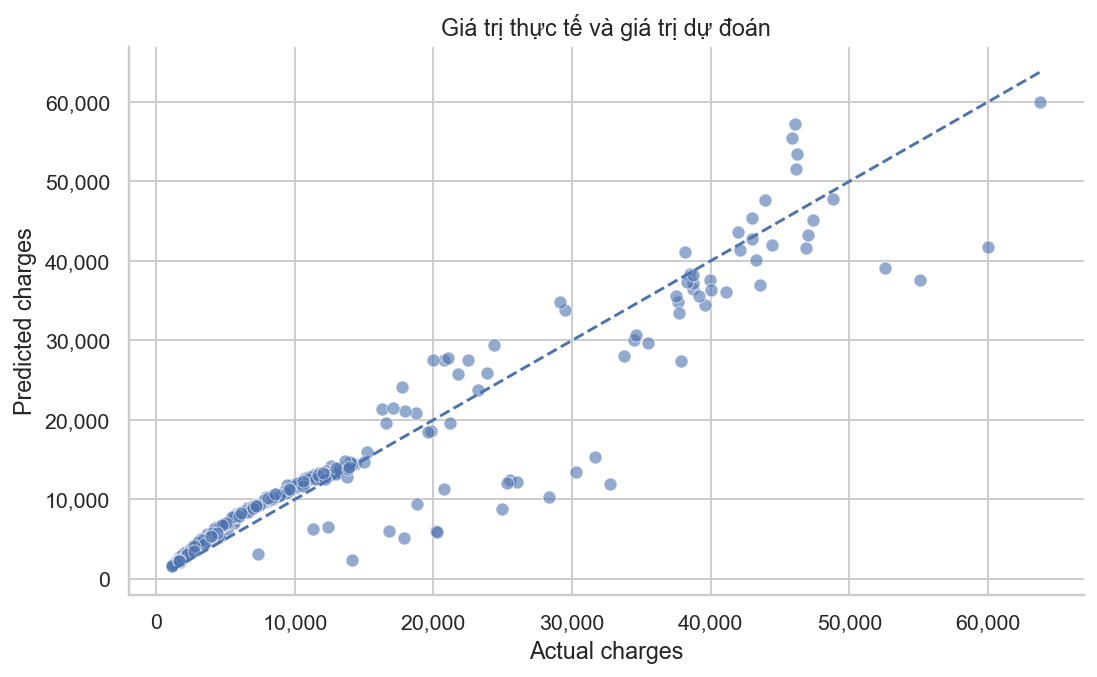

In [25]:
plt.figure(figsize=(8,5))
ax = sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, s=45)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

ax.set_title("Giá trị thực tế và giá trị dự đoán")
ax.set_xlabel("Actual charges")
ax.set_ylabel("Predicted charges")
ax.xaxis.set_major_formatter(money_fmt)
ax.yaxis.set_major_formatter(money_fmt)
sns.despine()
plt.tight_layout()
plt.show()